In [1]:
'''
Task to perform in phase 1:

Raw Data: 
Open
High
Low
Close
Volume

Trend Indicators:
SMA_20
SMA_50
EMA_20
EMA_50

Momentum Indicators:
RSI
MACD
Signal_Line

Volatility Indicators:
Daily_Return
Volatility
BB_Middle
BB_Upper
BB_Lower

Trading Signal:
Signal'''

'\nTask to perform in phase 1:\n\nRaw Data: \nOpen\nHigh\nLow\nClose\nVolume\n\nTrend Indicators:\nSMA_20\nSMA_50\nEMA_20\nEMA_50\n\nMomentum Indicators:\nRSI\nMACD\nSignal_Line\n\nVolatility Indicators:\nDaily_Return\nVolatility\nBB_Middle\nBB_Upper\nBB_Lower\n\nTrading Signal:\nSignal'

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

the basic EDA (Exploratory Data Analysis)

In [3]:
df = yf.download("AAPL",
                 start="2020-01-01",
                 end="2026-01-01")

df.columns = df.columns.get_level_values(0)

[*********************100%***********************]  1 of 1 completed


In [4]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1508 entries, 2020-01-02 to 2025-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1508 non-null   float64
 1   High    1508 non-null   float64
 2   Low     1508 non-null   float64
 3   Open    1508 non-null   float64
 4   Volume  1508 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 70.7 KB


In [5]:
df.isnull().sum()

Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
#Average stock price = 150
#Highest stock price = 260
#Lowest stock price = 70
df.describe()

Price,Close,High,Low,Open,Volume
count,1508.000000,1508.000000,1508.000000,1508.000000,1.508000e+03
mean,164.635762,166.317006,162.788386,164.474886,8.453734e+07
std,49.626454,49.917229,49.286415,49.583375,5.136424e+07
min,54.163704,55.160702,51.324800,55.059313,1.791060e+07
25%,131.178326,132.636083,129.816918,131.583422,5.075645e+07
50%,163.044121,165.172166,161.770210,163.302229,7.040210e+07
75%,197.198059,199.120396,194.347212,196.560474,1.005718e+08
max,285.659271,288.084759,282.774617,285.669263,4.265100e+08


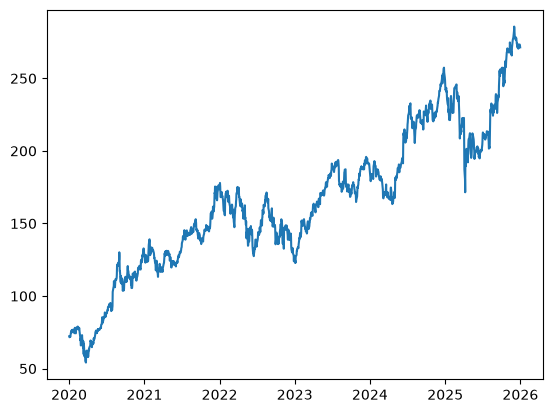

In [8]:
#This shows the stock's price movement over time.
plt.plot(df['Close'])

start Technical Analysis, which creates features that our AI model will later use

In [9]:
#A Simple Moving Average (SMA) is the average stock price over a specific number of previous days.
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

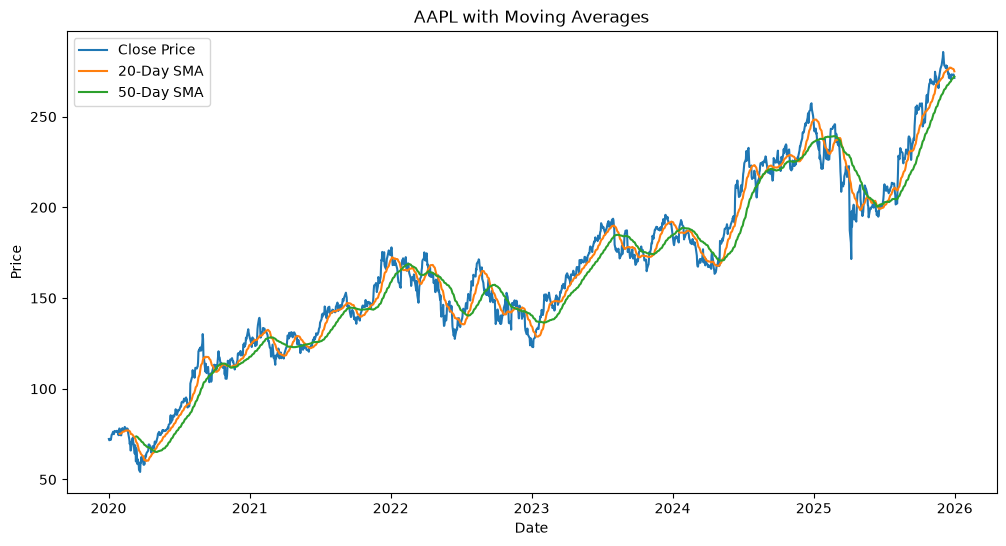

In [10]:
'''will see:

Blue line: actual stock price
Orange line: short-term trend
Green line: medium-term trend

When the orange line crosses the green line, that's an important market signal.'''
plt.figure(figsize=(12,6))

plt.plot(df['Close'], label='Close Price')
plt.plot(df['SMA_20'], label='20-Day SMA')
plt.plot(df['SMA_50'], label='50-Day SMA')

plt.title('AAPL with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

In [11]:
df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()
df['EMA_50'] = df['Close'].ewm(span=50, adjust=False).mean()
#EMA (Exponential Moving Average) is similar to SMA, but it gives more weight to recent prices.

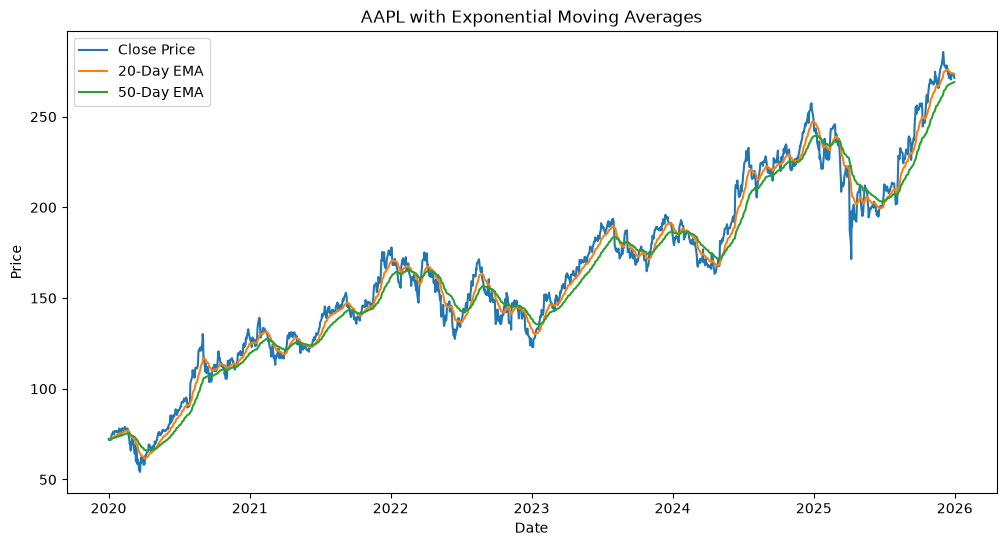

In [12]:
plt.figure(figsize=(12,6))

plt.plot(df['Close'], label='Close Price')
plt.plot(df['EMA_20'], label='20-Day EMA')
plt.plot(df['EMA_50'], label='50-Day EMA')

plt.title('AAPL with Exponential Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

plt.show()

In [13]:
# Daily Return tells us how much the stock price changed from one day to the next, in percentage terms.
df['Daily_Return'] = df['Close'].pct_change()

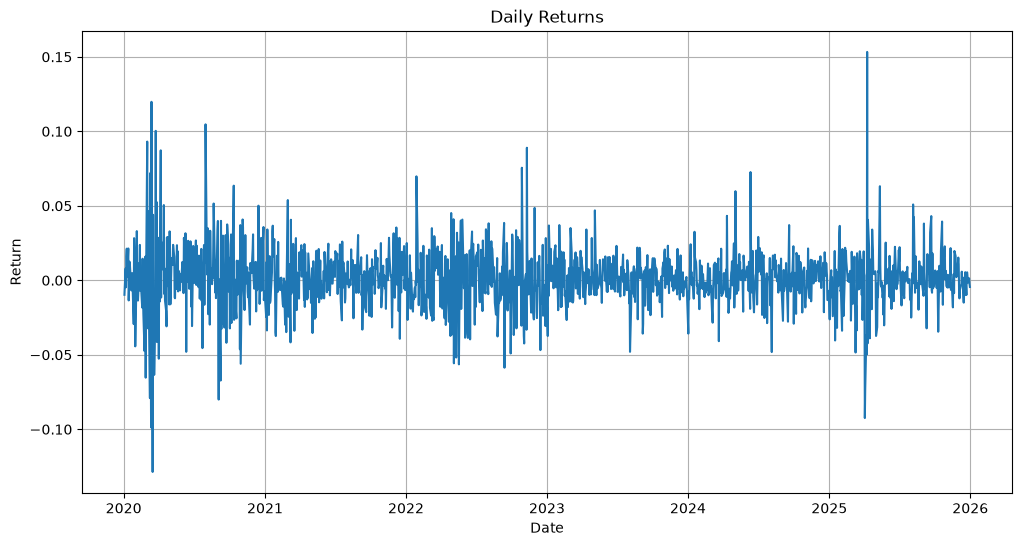

In [14]:
'''Values above zero → stock gained value.
Values below zero → stock lost value.
Large spikes → highly volatile market days'''
plt.figure(figsize=(12,6))

plt.plot(df['Daily_Return'])

plt.title('Daily Returns')
plt.xlabel('Date')
plt.ylabel('Return')

plt.grid(True)
plt.show()

In [15]:
'''Volatility measures how much the stock price fluctuates over a period of time.
Think of it as:
"How unstable or risky is the stock?"'''
df['Volatility'] = df['Daily_Return'].rolling(window=20).std()

In [16]:
df['Daily_Return'].rolling(window=20).std()

Date
2020-01-02         NaN
2020-01-03         NaN
2020-01-06         NaN
2020-01-07         NaN
2020-01-08         NaN
                ...   
2025-12-24    0.007907
2025-12-26    0.007884
2025-12-29    0.007798
2025-12-30    0.006813
2025-12-31    0.006140
Name: Daily_Return, Length: 1508, dtype: float64

In [17]:
df[['Daily_Return', 'Volatility']].tail()

Price,Daily_Return,Volatility
Date,,
2025-12-24,0.005324,0.007907
2025-12-26,-0.001497,0.007884
2025-12-29,0.001317,0.007798
2025-12-30,-0.002484,0.006813
2025-12-31,-0.004468,0.006140


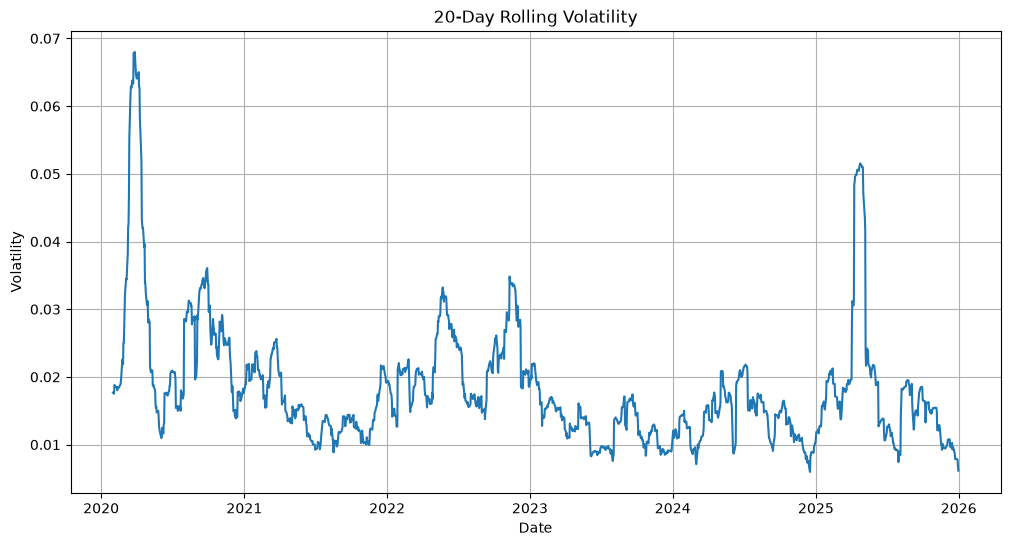

In [18]:
plt.figure(figsize=(12,6))

plt.plot(df['Volatility'])

plt.title('20-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')

plt.grid(True)
plt.show()

In [19]:
#This calculates price changes: Today's Price - Yesterday's Price
delta = df['Close'].diff()

In [20]:
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

In [21]:
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

In [22]:
# calculate RS and RSI
rs = avg_gain / avg_loss

df['RSI'] = 100 - (100 / (1 + rs))

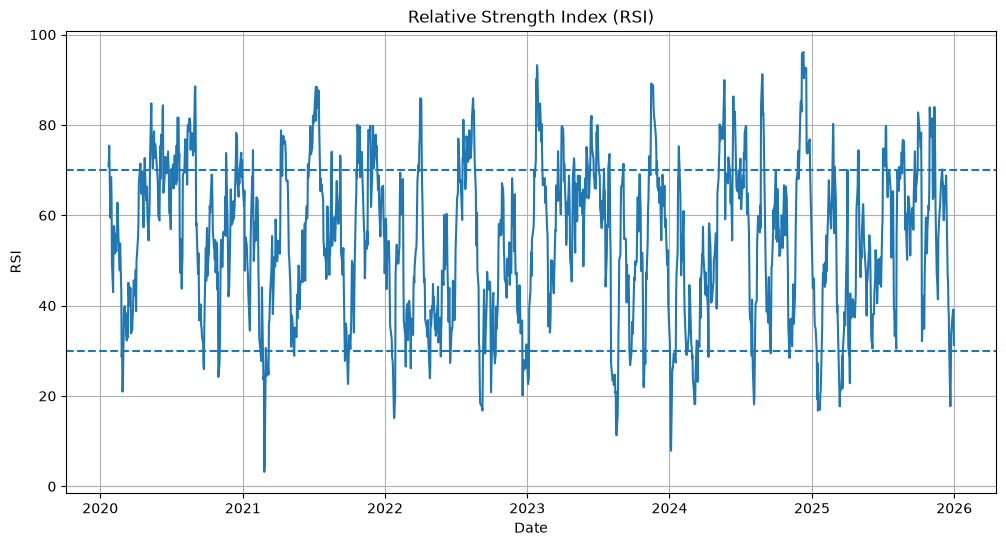

In [23]:
plt.figure(figsize=(12,6))

plt.plot(df['RSI'])

plt.axhline(70, linestyle='--')
plt.axhline(30, linestyle='--')

plt.title('Relative Strength Index (RSI)')
plt.xlabel('Date')
plt.ylabel('RSI')

plt.grid(True)
plt.show()

What is MACD?

MACD measures both:

Trend
Momentum

It helps answer:

"Is the stock gaining momentum or losing momentum?"

In [24]:
#Step 1: Calculate EMAs
exp1 = df['Close'].ewm(span=12, adjust=False).mean()
exp2 = df['Close'].ewm(span=26, adjust=False).mean()


In [25]:
#Step 2: Calculate MACD
df['MACD'] = exp1 - exp2

In [26]:
#Step 3: Calculate Signal Line
df['Signal_Line'] = df['MACD'].ewm(span=9, adjust=False).mean()

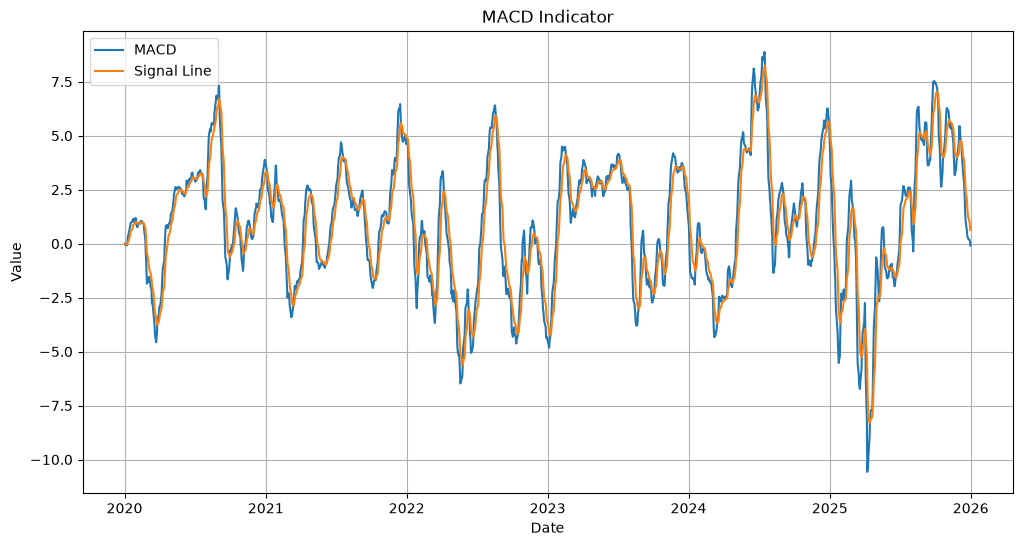

In [27]:
#Step 4: Plot MACD
plt.figure(figsize=(12,6))

plt.plot(df['MACD'], label='MACD')
plt.plot(df['Signal_Line'], label='Signal Line')

plt.title('MACD Indicator')
plt.xlabel('Date')
plt.ylabel('Value')

plt.legend()
plt.grid(True)

plt.show()

Bollinger Bands consist of three lines:

Line	                Formula
Middle Band	            20-day SMA
Upper Band	            SMA + (2 × Standard Deviation) -> Market may be overbought
Lower Band	            SMA - (2 × Standard Deviation) -> Market may be oversold

In [28]:
#Step 1: Calculate the middle band (20-day SMA)
df['BB_Middle'] = df['Close'].rolling(window=20).mean()

In [29]:
#Step 2: Calculate the standard deviation
std = df['Close'].rolling(window=20).std()

In [30]:
#Step 3: Calculate upper and lower bands
# Middle Band (20-day SMA)
df['BB_Middle'] = df['Close'].rolling(window=20).mean()

# Standard Deviation
std = df['Close'].rolling(window=20).std()

# Upper and Lower Bands
df['BB_Upper'] = df['BB_Middle'] + (2 * std)
df['BB_Lower'] = df['BB_Middle'] - (2 * std)

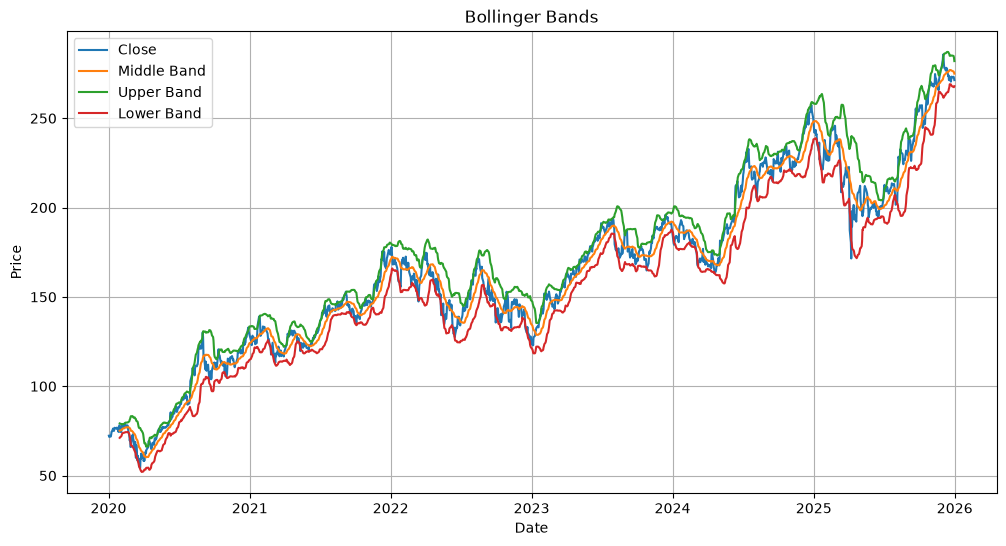

In [31]:
plt.figure(figsize=(12,6))

plt.plot(df['Close'], label='Close')
plt.plot(df['BB_Middle'], label='Middle Band')
plt.plot(df['BB_Upper'], label='Upper Band')
plt.plot(df['BB_Lower'], label='Lower Band')

plt.title('Bollinger Bands')
plt.xlabel('Date')
plt.ylabel('Price')

plt.legend()
plt.grid(True)

plt.show()

In [32]:
# Step 1: Create a Signal Column
df['Signal'] = 0

df.loc[df['SMA_20'] > df['SMA_50'], 'Signal'] = 1
df.loc[df['SMA_20'] < df['SMA_50'], 'Signal'] = -1

In [33]:
#Step 2: Check the results
df[['Close', 'SMA_20', 'SMA_50', 'Signal']].tail(20)

Price,Close,SMA_20,SMA_50,Signal
Date,,,,
2025-12-03,283.623047,273.244196,263.931802,1
2025-12-04,280.179443,273.784271,264.503427,1
2025-12-05,278.263000,274.246974,264.945780,1
2025-12-08,277.374664,274.730077,265.398487,1
2025-12-09,276.665955,275.116856,265.857562,1
2025-12-10,278.263000,275.293028,266.344588,1
2025-12-11,277.514404,275.520605,266.800290,1
2025-12-12,277.763947,275.786610,267.227477,1
2025-12-15,273.601654,275.871452,267.553668,1


In [34]:
#Step 3: Count signals
print(df['Signal'].value_counts())

Signal
 1    891
-1    568
 0     49
Name: count, dtype: int64


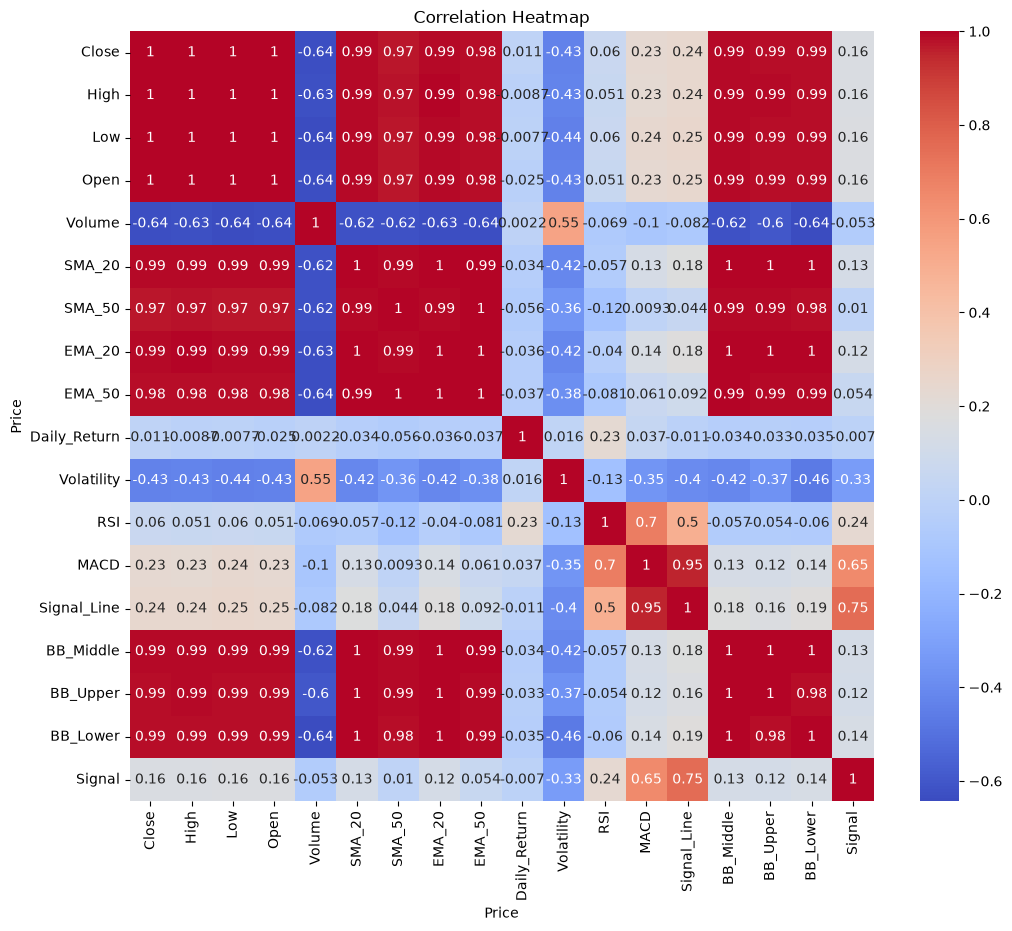

In [35]:
#Step 4: Correlation Heatmap
plt.figure(figsize=(12,10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

In [36]:
df.to_csv('alphatrade_phase1.csv')

In [37]:
df.head()
df.shape

(1508, 18)

In [38]:
'''
Quick recap of the concepts you learned:-
Concept	                                            Purpose
EDA	                                        Understand and clean the data
SMA	                                        Identify trends
EMA	                                        Identify recent trends faster
Daily Return	                            Measure percentage price changes
Volatility	                                Measure risk
RSI	                                        Detect overbought/oversold conditions
MACD	                                    Measure trend and momentum
Bollinger Bands	                            Measure volatility and possible reversals
Signal	                                    Generate buy/sell decisions
'''

'\nQuick recap of the concepts you learned:-\nConcept\t                                            Purpose\nEDA\t                                        Understand and clean the data\nSMA\t                                        Identify trends\nEMA\t                                        Identify recent trends faster\nDaily Return\t                            Measure percentage price changes\nVolatility\t                                Measure risk\nRSI\t                                        Detect overbought/oversold conditions\nMACD\t                                    Measure trend and momentum\nBollinger Bands\t                            Measure volatility and possible reversals\nSignal\t                                    Generate buy/sell decisions\n'

In [39]:
print(df.shape)
print(df.columns)
print(df.isnull().sum())

(1508, 18)
Index(['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_20', 'SMA_50', 'EMA_20',
       'EMA_50', 'Daily_Return', 'Volatility', 'RSI', 'MACD', 'Signal_Line',
       'BB_Middle', 'BB_Upper', 'BB_Lower', 'Signal'],
      dtype='str', name='Price')
Price
Close            0
High             0
Low              0
Open             0
Volume           0
SMA_20          19
SMA_50          49
EMA_20           0
EMA_50           0
Daily_Return     1
Volatility      20
RSI             13
MACD             0
Signal_Line      0
BB_Middle       19
BB_Upper        19
BB_Lower        19
Signal           0
dtype: int64


In [40]:
df.to_csv('alphatrade_phase1.csv', index=True)
df.to_csv('alphatrade_phase1.csv')